# ASX Stock Analysis

In [72]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## Historical data for Commonwealth Bank Stock

[*********************100%***********************]  1 of 1 completed


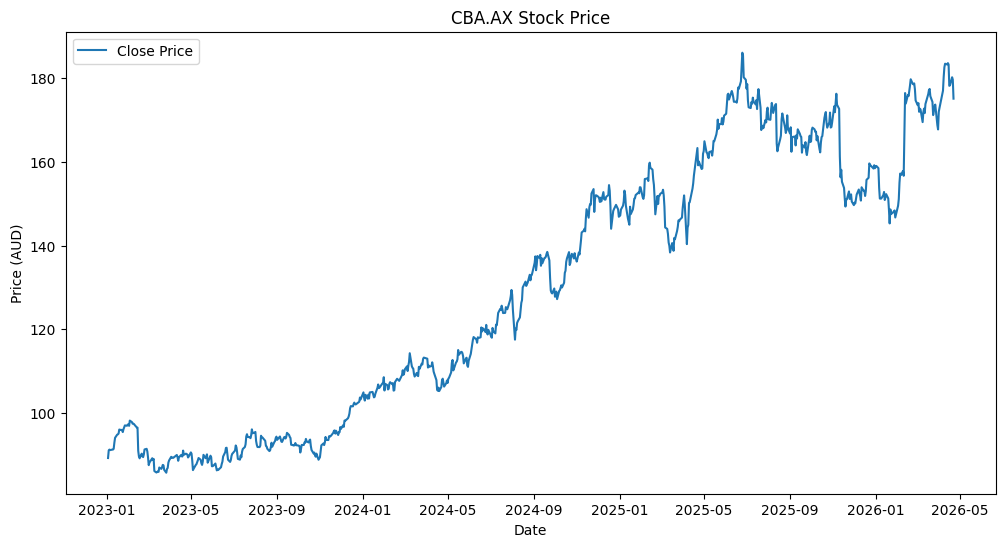

In [73]:
ticker = 'CBA.AX'
data = yf.download(ticker, start='2023-01-01', end='2026-04-23')

plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price')
plt.title(f'{ticker} Stock Price')
plt.xlabel('Date')
plt.ylabel('Price (AUD)')
plt.legend()
plt.show()

## Daily returns

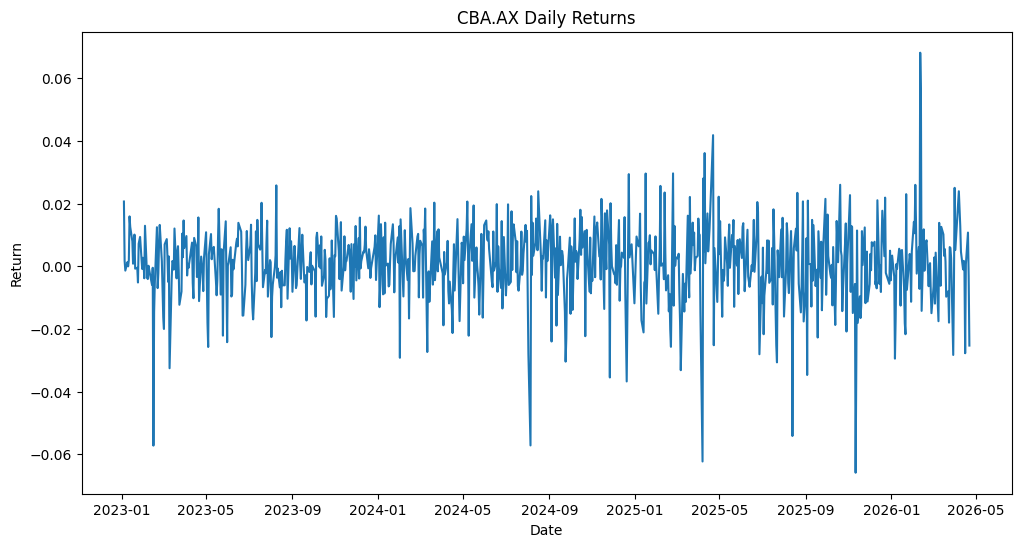

In [74]:
data['Daily Return'] = data['Close'].pct_change()

plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'])
plt.title(f'{ticker} Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.show()

## Volatility across stocks

In [75]:
tickers = ['CBA.AX', 'BHP.AX', 'CSL.AX', 'MQG.AX', 'WBC.AX']

for t in tickers:
    df = yf.download(t, start='2023-01-01', auto_adjust=True)
    start_price = df['Close'].iloc[0].item()
    end_price = df['Close'].iloc[-1].item()
    total_return = ((end_price - start_price) / start_price * 100)
    volatility = df['Close'].pct_change().std().item() * 100
    print(f"{t}: Start ${start_price:.2f} → End ${end_price:.2f} | Return: {total_return:.1f}% | Daily Volatility: {volatility:.2f}%")

[*********************100%***********************]  1 of 1 completed


CBA.AX: Start $89.31 → End $173.38 | Return: 94.1% | Daily Volatility: 1.23%


[*********************100%***********************]  1 of 1 completed


BHP.AX: Start $38.20 → End $56.03 | Return: 46.7% | Daily Volatility: 1.46%


[*********************100%***********************]  1 of 1 completed


CSL.AX: Start $265.66 → End $129.00 | Return: -51.4% | Daily Volatility: 1.51%


[*********************100%***********************]  1 of 1 completed


MQG.AX: Start $148.18 → End $230.60 | Return: 55.6% | Daily Volatility: 1.43%


[*********************100%***********************]  1 of 1 completed

WBC.AX: Start $19.24 → End $39.12 | Return: 103.3% | Daily Volatility: 1.21%


## Moving averages

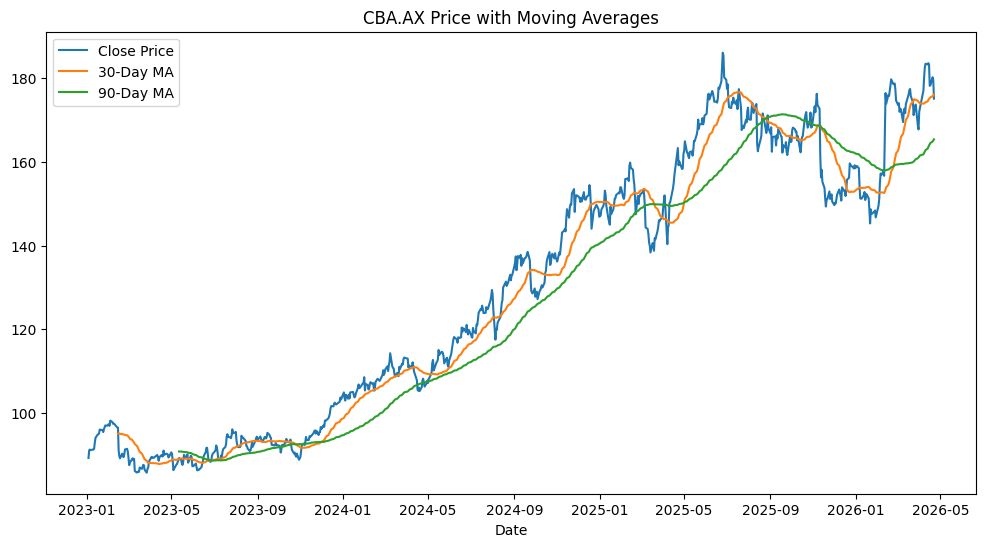

In [76]:
data['MA30'] = data['Close'].rolling(window=30).mean()
data['MA90'] = data['Close'].rolling(window=90).mean()

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA30'], label='30-Day MA')
plt.plot(data['MA90'], label='90-Day MA')
plt.title(f'{ticker} Price with Moving Averages')
plt.xlabel('Date')
plt.legend()
plt.show()

## Stock Performance Insights (2023–2026)

### CBA.AX (Commonwealth Bank of Australia): 
### CBA delivered the strongest risk-adjusted performance of the five stocks, returning 94.1% with the lowest daily volatility at 1.23%.This is as expected with its position as Australia's largest bank. It's steady, predictable, and heavily tied to the housing market which remained consistent over this period.

### BHP.AX (BHP Group):
### BHP returned 46.7% with a daily volatility of 1.46%. The higher volatility relative to the banks reflects its exposure to commodity prices, which tends to fluctuate with global demand. Nonetheless, it's a solid return, though noticeably lower than the financial sector over this period.

### CSL.AX (CSL Limited):
### CSL was the clear underperformer, returning -51.4% over the period with a daily volatility of 1.51%. This is notable given CSL's reputation as one of Australia's strongest companies historically. The negative return suggests the stock may have been overvalued coming into 2023 or faced sector-specific headwinds.

### MQG.AX (Macquarie Group):
### Macquarie returned 55.6% with 1.43% daily volatility. As an investment bank, its performance is more sensitive to market conditions and deal activity than a retail bank like CBA or WBC. This likely explains the slightly higher volatility despite a strong return.

### WBC.AX (Westpac):
### Westpac posted the highest return at 103.3% with the second lowest volatility at 1.21%. Alongside CBA, this reinforces the strength of Australian banking stocks over this period, where Westpac slightly outperformed its larger rival on a raw return basis.